## HW3

### 실험 A


In [30]:
#
# 사용할 라이브러리
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

from sklearn.datasets import load_digits, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from torch.utils.data import TensorDataset, DataLoader

In [31]:
# GPU가 사용 가능하면 cuda를 사용하고,
# GPU가 없으면 CPU를 사용합니다
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)
np.random.seed(42)



# 1. Digits Dataset
digits = load_digits()

# 입력데이터 X 8*8
X = digits.data

# 정답 y
y = digits.target

# 입력 데이터의 값 범위
scaler = StandardScaler()
X = scaler.fit_transform(X)

# stratify=y는 각 숫자 클래스의 비율을 학습/테스트에 비슷하게 유지해줍니다.
# 20%는 테스터 데이터로 쓰기.
# stratify=y는 각 숫자 클래스의 비율을 학습/테스트에 비슷하게 유지

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 입력값 X는 실수 계산이 필요하므로 float32로 변환
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

# 정답 y는 클래스 번호이므로 long 타입으로 변환
# CrossEntropyLoss는 정답 라벨이 long 타입
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# batch_size=64는 한 번에 64개 데이터를 학습
# shuffle=True는 학습할 때 데이터 순서를 셔플
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# 테스트 데이터는 순서를 섞을 필요가 없으므로 shuffle=False이여야 함
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 입력 크기
input_size = X_train.shape[1]

# 출력 클래스 개수. 0-9 10개
num_classes = 10

print("입력 크기 :", input_size)
print("클래스 개수 :", num_classes)

입력 크기 : 64
클래스 개수 : 10


In [32]:
# 2. MLP 모델 정의

#MLP 모델 클래스
class MLP(nn.Module):

    # input_size: 입력 데이터 크기
    # num_classes: 출력 클래스 개수
    # activation: 사용할 활성화 함수 이름
    def __init__(self, input_size, num_classes, activation="relu"):
        super().__init__()

        if activation == "relu":
            act = nn.ReLU()

        elif activation == "leakyrelu":
            act = nn.LeakyReLU(negative_slope=0.01)

        elif activation == "sigmoid":
            act = nn.Sigmoid()

        self.net = nn.Sequential(
            # 입력층 - 첫 번째 은닉층
            nn.Linear(input_size, 256),

            # 첫 번째 활성화 함수
            act,

            # 첫 번째 은닉층 - 두 번째 은닉층
            nn.Linear(256, 128),

            # 두 번째 활성화 함수
            act,

            # 두 번째 은닉층 - 출력층
            # 출력은 클래스 개수만큼 나와야 한다.
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [33]:
# 평가하기
def evaluate(model, loader):
    model.eval()

    preds = []
    labels = []

    # 평가할때는 기울기 계산을 하지 않는다. (학습하지 않기 때문)
    with torch.no_grad():

        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            # 모델 예측값을 계산
            outputs = model(x_batch)

            # 가장 점수가 높은 클래스 번호를 예측값으로 선택.
            predicted = torch.argmax(outputs, dim=1)

            preds.extend(predicted.cpu().numpy())
            labels.extend(y_batch.cpu().numpy())

    # 전체 예측값과 실제 정답을 비교하여 정확도를 계산
    acc = accuracy_score(labels, preds)

    return acc

In [34]:
# 3. 학습 함수

def train_model(
    model,
    train_loader,
    test_loader,
    loss_type="ce",
    optimizer_name="adam",
    lr=0.001,
    epochs=30,
    use_scheduler=False
):

    model = model.to(device)
    # 손실 함수 선택
    if loss_type == "ce":
        loss_fn = nn.CrossEntropyLoss()

    elif loss_type == "mse":
        loss_fn = nn.MSELoss()


# 옵티마이저 선택
    if optimizer_name == "sgd":
        # 경사하강법
        optimizer = optim.SGD(model.parameters(), lr=lr)

    elif optimizer_name == "momentum":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    elif optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)


   # 학습율 스케줄러
    scheduler = None

    if use_scheduler:
        #  epoch마다 학습률이 90%로 감소
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

    # loss와 accuracy를 저장 리스트
    train_losses = []
    train_accs = []
    test_accs = []



    # Epoch 반복
    for epoch in range(epochs):
        model.train()

        total_loss = 0
        all_preds = []
        all_labels = []

        for x_batch, y_batch in train_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            # 초기화
            optimizer.zero_grad()
            outputs = model(x_batch)

            # Loss 계산
            if loss_type == "ce":
                loss = loss_fn(outputs, y_batch)

            elif loss_type == "mse":

                y_onehot = torch.zeros(y_batch.size(0), num_classes).to(device)
                #  one-hot 형태 변경필요
                y_onehot.scatter_(1, y_batch.view(-1, 1), 1)
                outputs_softmax = torch.softmax(outputs, dim=1)

                # softmax 결과와 one-hot 정답 사이의 MSE를 계산합니다.
                loss = loss_fn(outputs_softmax, y_onehot)

            # 역전파와 파라미터 업데이트
            # loss를 기준으로 각 파라미터의 gradient를 계산
            loss.backward()

            optimizer.step()

            total_loss += loss.item()

            predicted = torch.argmax(outputs, dim=1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

        # Scheduler를 사용하는 경우 epoch이 끝날 때 학습률을 감소
        if scheduler is not None:
            scheduler.step()

        # 한 epoch의 평균 loss를 계산
        avg_loss = total_loss / len(train_loader)

        # 학습 데이터에 대한 정확도를 계산
        train_acc = accuracy_score(all_labels, all_preds)

        # 테스트 데이터에 대한 정확도를 계산
        test_acc = evaluate(model, test_loader)

        train_losses.append(avg_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        # 현재 epoch의 결과를 출력합니다.
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {avg_loss:.4f}, "
            f"Train Acc: {train_acc:.4f}, "
            f"Test Acc: {test_acc:.4f}"
        )

    return {
        "model": model,
        "losses": train_losses,
        "train_accs": train_accs,
        "test_accs": test_accs,
        "final_acc": test_accs[-1],
        "min_loss": min(train_losses)
    }

In [35]:
# 6. 그래프 출력

def plot_results(results, title):
    # Loss 그래프
    plt.figure(figsize=(8, 5))

    for name, result in results.items():
        plt.plot(result["losses"], label=name)

    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Accuracy 그래프
    plt.figure(figsize=(8, 5))

    for name, result in results.items():
        plt.plot(result["test_accs"], label=name)

    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

Epoch [1/30] Loss: 1.7341, Train Acc: 0.6500, Test Acc: 0.8000
Epoch [2/30] Loss: 0.6345, Train Acc: 0.8720, Test Acc: 0.9139
Epoch [3/30] Loss: 0.2412, Train Acc: 0.9429, Test Acc: 0.9472
Epoch [4/30] Loss: 0.1285, Train Acc: 0.9701, Test Acc: 0.9694
Epoch [5/30] Loss: 0.0802, Train Acc: 0.9875, Test Acc: 0.9639
Epoch [6/30] Loss: 0.0547, Train Acc: 0.9930, Test Acc: 0.9722
Epoch [7/30] Loss: 0.0432, Train Acc: 0.9958, Test Acc: 0.9694
Epoch [8/30] Loss: 0.0295, Train Acc: 0.9979, Test Acc: 0.9750
Epoch [9/30] Loss: 0.0245, Train Acc: 0.9972, Test Acc: 0.9667
Epoch [10/30] Loss: 0.0169, Train Acc: 0.9986, Test Acc: 0.9694
Epoch [11/30] Loss: 0.0132, Train Acc: 0.9986, Test Acc: 0.9750
Epoch [12/30] Loss: 0.0111, Train Acc: 0.9993, Test Acc: 0.9722
Epoch [13/30] Loss: 0.0093, Train Acc: 1.0000, Test Acc: 0.9722
Epoch [14/30] Loss: 0.0073, Train Acc: 1.0000, Test Acc: 0.9722
Epoch [15/30] Loss: 0.0063, Train Acc: 1.0000, Test Acc: 0.9722
Epoch [16/30] Loss: 0.0055, Train Acc: 1.0000, Te

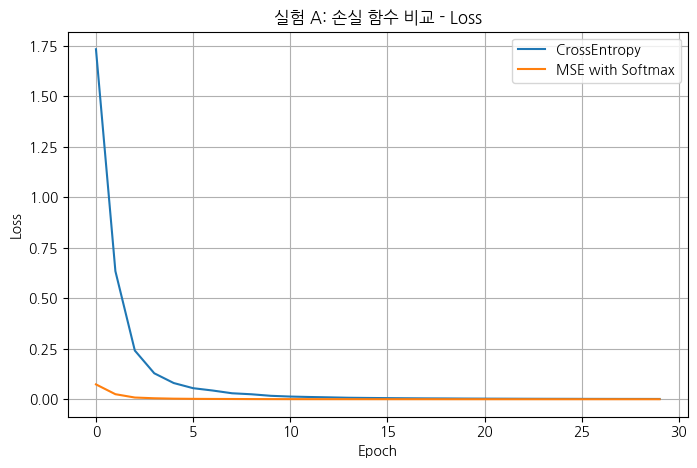

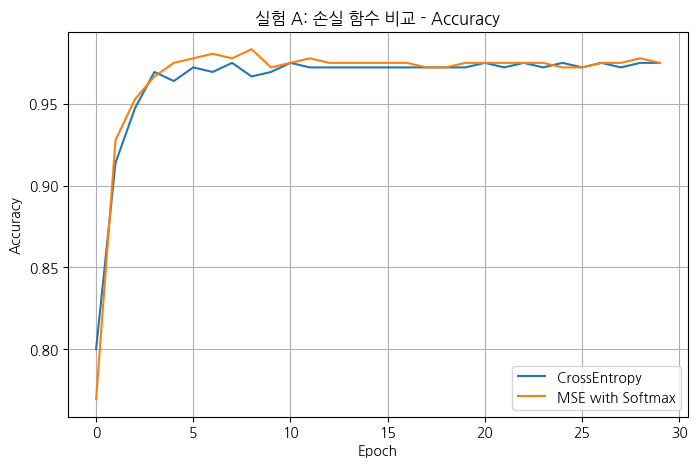

In [36]:

# CrossEntropyLoss vs MSELoss
exp_a_results = {}

# 1. CrossEntropyLoss 실험

model_ce = MLP(input_size, num_classes, activation="relu")

# CrossEntropyLoss를 사용하여 학습
exp_a_results["CrossEntropy"] = train_model(
    model_ce,
    train_loader,
    test_loader,
    loss_type="ce",          # CrossEntropyLoss 사용
    optimizer_name="adam",   # Adam optimizer 사용
    lr=0.001,
    epochs=30
)

# 2) MSELoss 실험

# 같은 구조의 새로운 모델을 생성
model_mse = MLP(input_size, num_classes, activation="relu")

# MSELoss를 사용하여 학습.
exp_a_results["MSE with Softmax"] = train_model(
    model_mse,
    train_loader,
    test_loader,
    loss_type="mse",         # MSELoss 사용
    optimizer_name="adam",   # optimizer는 동일하게 Adam 사용
    lr=0.001,
    epochs=30
)


plot_results(exp_a_results, "실험 A: 손실 함수 비교")

In [37]:
# 실험 A 비교 표

exp_a_table = pd.DataFrame({
    "실험 항목": ["CrossEntropy", "MSE with Softmax"],
    "최종 정확도": [
        exp_a_results["CrossEntropy"]["final_acc"],
        exp_a_results["MSE with Softmax"]["final_acc"]
    ],
    "Loss 최솟값": [
        exp_a_results["CrossEntropy"]["min_loss"],
        exp_a_results["MSE with Softmax"]["min_loss"]
    ]
})

exp_a_table

,실험 항목,최종 정확도,Loss 최솟값
0,CrossEntropy,0.975,0.001295
1,MSE with Softmax,0.975,0.000020


## 실험 B

In [38]:
# 실험 B용 make_moons 데이터셋

from sklearn.datasets import make_moons

# make_moons 생성
# n_samples: 데이터 개수
# noise: 데이터에 약간의 노이즈 추가
X_moon, y_moon = make_moons(
    n_samples=1000,
    noise=0.2,
    random_state=42
)

# 데이터 분리
X_train_moon, X_test_moon, y_train_moon, y_test_moon = train_test_split(
    X_moon,
    y_moon,
    test_size=0.2,
    random_state=42
)

# tensor 변환
X_train_moon = torch.FloatTensor(X_train_moon)
X_test_moon = torch.FloatTensor(X_test_moon)

y_train_moon = torch.LongTensor(y_train_moon)
y_test_moon = torch.LongTensor(y_test_moon)

# DataLoader 생성
train_dataset_moon = TensorDataset(
    X_train_moon,
    y_train_moon
)

test_dataset_moon = TensorDataset(
    X_test_moon,
    y_test_moon
)

train_loader_moon = DataLoader(
    train_dataset_moon,
    batch_size=64,
    shuffle=True
)

test_loader_moon = DataLoader(
    test_dataset_moon,
    batch_size=64,
    shuffle=False
)

In [39]:
# 실험 B 모델 만들기

# 활성화 함수만 바꿀 수 있게 함

class MLP_B(nn.Module):

    def __init__(self, activation_name):
        super(MLP_B, self).__init__()

        # moons는 x, y 두개
        self.fc1 = nn.Linear(2, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

        # 입력받은 이름에 따라 활성화 함수를 선택
        if activation_name == "relu":
            self.act1 = nn.ReLU()
            self.act2 = nn.ReLU()

        elif activation_name == "leakyrelu":
            self.act1 = nn.LeakyReLU(0.01)
            self.act2 = nn.LeakyReLU(0.01)

        elif activation_name == "sigmoid":
            self.act1 = nn.Sigmoid()
            self.act2 = nn.Sigmoid()

    def forward(self, x):

        x = self.fc1(x)
        x = self.act1(x)

        # 첫 번째 은닉층 activation 저장
        self.hidden1 = x

        x = self.fc2(x)
        x = self.act2(x)

        # 두 번째 은닉층 activation 저장
        self.hidden2 = x

        x = self.fc3(x)

        return x

In [40]:
# 실험 B 학습 함수

def train_activation_model(activation_name):

    model = MLP_B(activation_name).to(device)

    loss_function = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    epoch_list = []
    loss_list = []
    acc_list = []

    epochs = 30

    for epoch in range(epochs):

        model.train()

        total_loss = 0
        predict_list = []
        label_list = []

        for x_batch, y_batch in train_loader_moon:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            output = model(x_batch)

            loss = loss_function(output, y_batch)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

            predict = torch.argmax(output, dim=1)

            predict_list.extend(predict.cpu().numpy())
            label_list.extend(y_batch.cpu().numpy())

        avg_loss = total_loss / len(train_loader)

        # 테스트 정확도 계산
        model.eval()

        test_predict = []
        test_label = []

        with torch.no_grad():

            for x_batch, y_batch in test_loader_moon:

                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                output = model(x_batch)

                predict = torch.argmax(output, dim=1)

                test_predict.extend(predict.cpu().numpy())
                test_label.extend(y_batch.cpu().numpy())

        test_acc = accuracy_score(test_label, test_predict)

        epoch_list.append(epoch + 1)
        loss_list.append(avg_loss)
        acc_list.append(test_acc)

        print(
            activation_name,
            "Epoch:",
            epoch + 1,
            "Loss:",
            avg_loss,
            "Test Accuracy:",
            test_acc
        )

    return model, epoch_list, loss_list, acc_list

In [41]:
# 실험 B 실행

relu_model, relu_epoch, relu_loss, relu_acc = train_activation_model("relu")

leaky_model, leaky_epoch, leaky_loss, leaky_acc = train_activation_model("leakyrelu")

sigmoid_model, sigmoid_epoch, sigmoid_loss, sigmoid_acc = train_activation_model("sigmoid")

relu Epoch: 1 Loss: 0.7704876531725344 Test Accuracy: 0.775
relu Epoch: 2 Loss: 0.23430935908918796 Test Accuracy: 0.81
relu Epoch: 3 Loss: 0.1714537843413975 Test Accuracy: 0.855
relu Epoch: 4 Loss: 0.1554170231456342 Test Accuracy: 0.89
relu Epoch: 5 Loss: 0.13395294482293335 Test Accuracy: 0.91
relu Epoch: 6 Loss: 0.12392356765011082 Test Accuracy: 0.915
relu Epoch: 7 Loss: 0.10983733120171921 Test Accuracy: 0.935
relu Epoch: 8 Loss: 0.10058516425930936 Test Accuracy: 0.955
relu Epoch: 9 Loss: 0.0871293201394703 Test Accuracy: 0.965
relu Epoch: 10 Loss: 0.07752033906138461 Test Accuracy: 0.965
relu Epoch: 11 Loss: 0.07201198051157205 Test Accuracy: 0.975
relu Epoch: 12 Loss: 0.0635575567898543 Test Accuracy: 0.98
relu Epoch: 13 Loss: 0.05943748306321061 Test Accuracy: 0.975
relu Epoch: 14 Loss: 0.05579184659797212 Test Accuracy: 0.98
relu Epoch: 15 Loss: 0.051511273111986076 Test Accuracy: 0.98
relu Epoch: 16 Loss: 0.048606920663429344 Test Accuracy: 0.975
relu Epoch: 17 Loss: 0.047

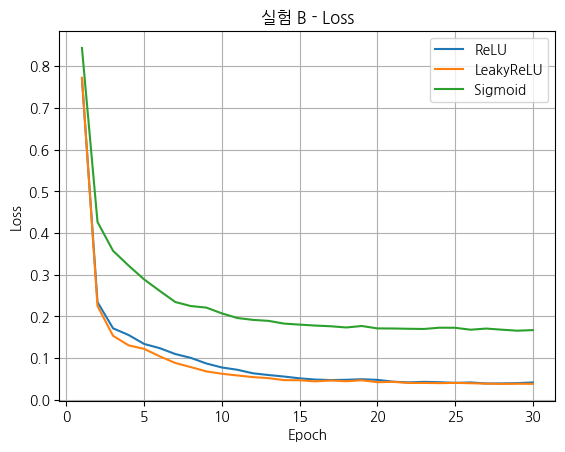

In [42]:
# 실험 B Loss 그래프

plt.plot(relu_epoch, relu_loss, label="ReLU")
plt.plot(leaky_epoch, leaky_loss, label="LeakyReLU")
plt.plot(sigmoid_epoch, sigmoid_loss, label="Sigmoid")

plt.title("실험 B - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

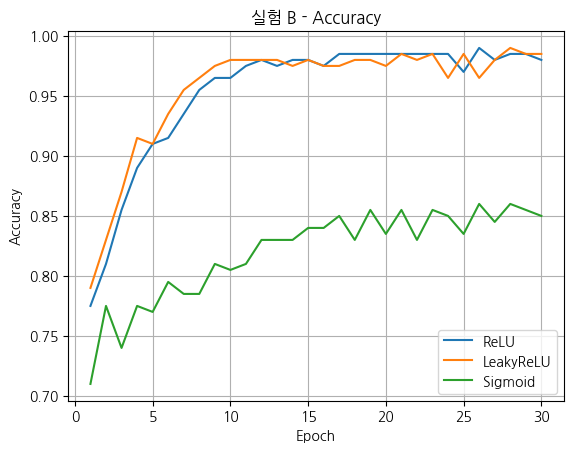

In [43]:
# 실험 B Accuracy 그래프

plt.plot(relu_epoch, relu_acc, label="ReLU")
plt.plot(leaky_epoch, leaky_acc, label="LeakyReLU")
plt.plot(sigmoid_epoch, sigmoid_acc, label="Sigmoid")

plt.title("실험 B - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

In [44]:
# Dead ReLU 비율 계산 함수

def check_dead_relu(model):

    model.eval()

    dead1_list = []
    dead2_list = []

    with torch.no_grad():

         for x_batch, y_batch in test_loader_moon:

            x_batch = x_batch.to(device)

            output = model(x_batch)

            # hidden 값이 0인 비율 계산
            dead1 = (model.hidden1 == 0).float().mean().item()
            dead2 = (model.hidden2 == 0).float().mean().item()

            dead1_list.append(dead1)
            dead2_list.append(dead2)

    layer1_dead = np.mean(dead1_list)
    layer2_dead = np.mean(dead2_list)

    return layer1_dead, layer2_dead

In [45]:
# ReLU, LeakyReLU, Sigmoid의 0 비율 확인

relu_dead1, relu_dead2 = check_dead_relu(relu_model)
leaky_dead1, leaky_dead2 = check_dead_relu(leaky_model)
sigmoid_dead1, sigmoid_dead2 = check_dead_relu(sigmoid_model)

dead_table = pd.DataFrame({
    "활성화 함수": ["ReLU", "LeakyReLU", "Sigmoid"],
    "Layer1 0 비율": [relu_dead1, leaky_dead1, sigmoid_dead1],
    "Layer2 0 비율": [relu_dead2, leaky_dead2, sigmoid_dead2],
    "최종 정확도": [relu_acc[-1], leaky_acc[-1], sigmoid_acc[-1]]
})

dead_table

,활성화 함수,Layer1 0 비율,Layer2 0 비율,최종 정확도
0,ReLU,0.448166,0.438232,0.980
1,LeakyReLU,0.000000,0.000000,0.985
2,Sigmoid,0.000000,0.000000,0.850


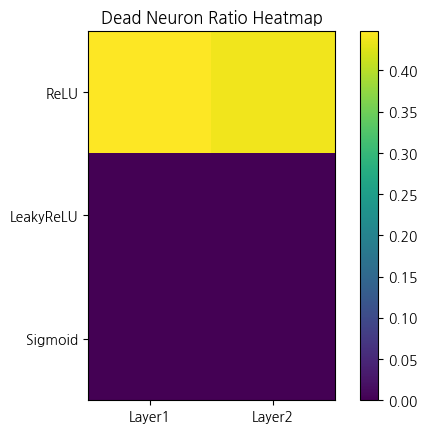

In [46]:
# Dead ReLU 비율 히트맵

heatmap_data = [
    [relu_dead1, relu_dead2],
    [leaky_dead1, leaky_dead2],
    [sigmoid_dead1, sigmoid_dead2]
]

plt.imshow(heatmap_data)

plt.xticks([0, 1], ["Layer1", "Layer2"])
plt.yticks([0, 1, 2], ["ReLU", "LeakyReLU", "Sigmoid"])

plt.colorbar()
plt.title("Dead Neuron Ratio Heatmap")

plt.show()

In [47]:
# Activation 분포 확인 함수

def show_activation_histogram(model, title):

    model.eval()

    with torch.no_grad():

        # 테스트 데이터 중 첫 번째 batch만 사용
         for x_batch, y_batch in test_loader_moon:

            x_batch = x_batch.to(device)

            output = model(x_batch)

            hidden1 = model.hidden1.cpu().numpy().flatten()
            hidden2 = model.hidden2.cpu().numpy().flatten()

            break

    plt.hist(hidden1, bins=30)
    plt.title(title + " Layer1 Activation")
    plt.xlabel("Activation Value")
    plt.ylabel("Count")
    plt.grid()
    plt.show()

    plt.hist(hidden2, bins=30)
    plt.title(title + " Layer2 Activation")
    plt.xlabel("Activation Value")
    plt.ylabel("Count")
    plt.grid()
    plt.show()

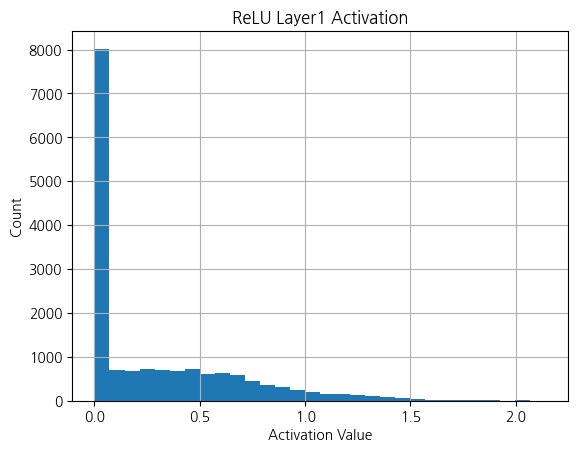

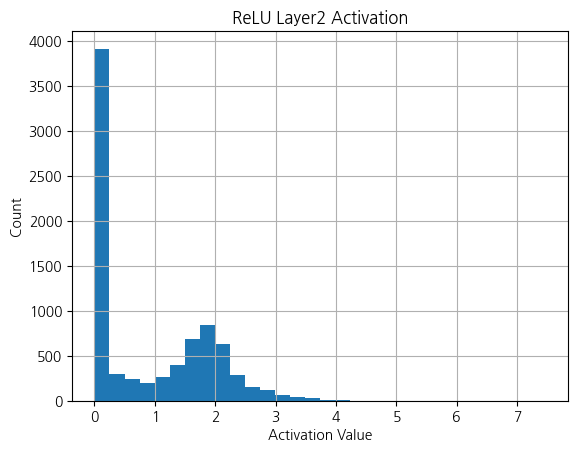

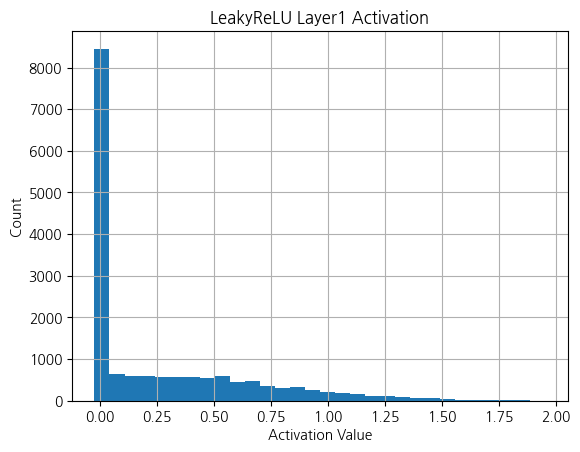

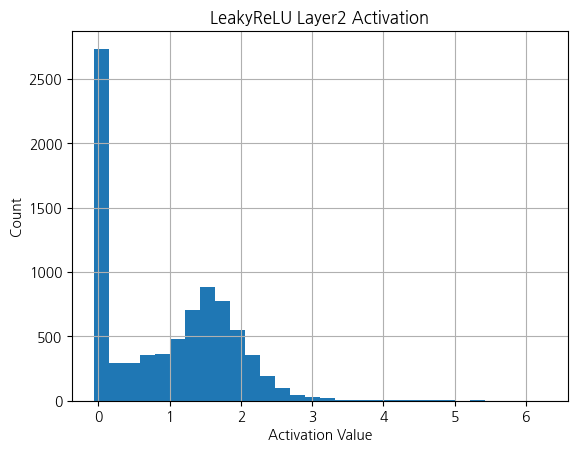

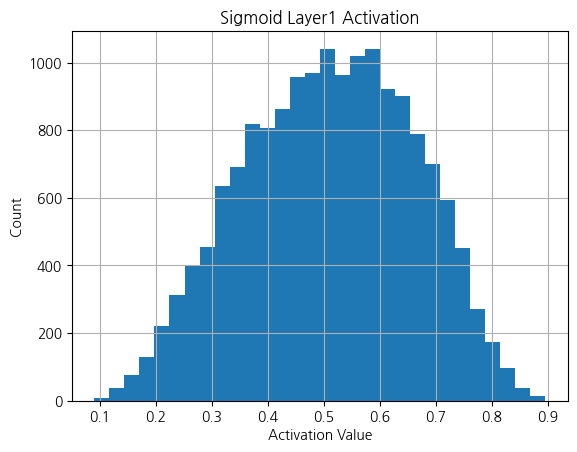

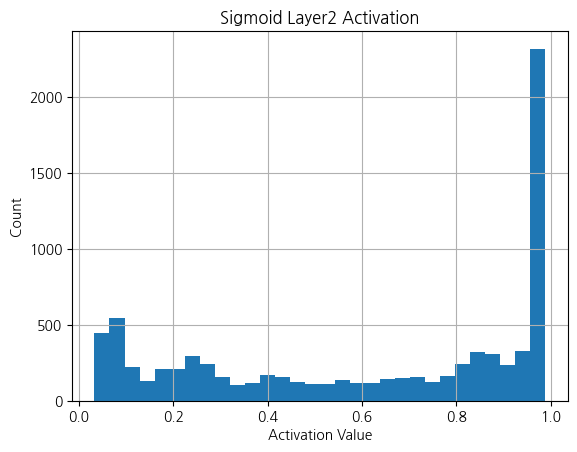

In [48]:
# Activation 분포 그래프

show_activation_histogram(relu_model, "ReLU")
show_activation_histogram(leaky_model, "LeakyReLU")
show_activation_histogram(sigmoid_model, "Sigmoid")

## 실험 C

In [49]:
# 실험 C용 모델
# 실험 B와 다르게 activation은 ReLU로 고정
# optimizer만 바꿔서 비교

class MLP_C(nn.Module):

    def __init__(self):
        super(MLP_C, self).__init__()

        self.fc1 = nn.Linear(64, 256)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.fc1(x)
        x = self.relu1(x)

        x = self.fc2(x)
        x = self.relu2(x)

        x = self.fc3(x)

        return x

In [50]:
# 실험 C 학습 함수

def train_optimizer_model(optimizer_name, learning_rate):

    # optimizer마다 같은 구조의 새 모델로 실험
    model = MLP_C().to(device)

    # 손실 함수는 CrossEntropy로 고정
    loss_function = nn.CrossEntropyLoss()

    # optimizer 선택
    if optimizer_name == "sgd":
        optimizer = optim.SGD(
            model.parameters(),
            lr=learning_rate
        )

    elif optimizer_name == "momentum":
        optimizer = optim.SGD(
            model.parameters(),
            lr=learning_rate,
            momentum=0.9
        )

    elif optimizer_name == "adam":
        optimizer = optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    scheduler = optim.lr_scheduler.ExponentialLR(
        optimizer,
        gamma=0.9
    )

    epoch_list = []
    loss_list = []
    acc_list = []

    epochs = 30

    for epoch in range(epochs):

        model.train()

        total_loss = 0
        predict_list = []
        label_list = []

        for x_batch, y_batch in train_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            # 이전 gradient 초기화
            optimizer.zero_grad()

            # 예측
            output = model(x_batch)

            # loss 계신
            loss = loss_function(output, y_batch)

            # gradient 계산
            loss.backward()

            # 파라미터 업데이트
            optimizer.step()

            total_loss += loss.item()

            predict = torch.argmax(output, dim=1)

            predict_list.extend(predict.cpu().numpy())
            label_list.extend(y_batch.cpu().numpy())

        scheduler.step()

        avg_loss = total_loss / len(train_loader)

        # 테스트 정확도 계산
        model.eval()

        test_predict = []
        test_label = []

        with torch.no_grad():

             for x_batch, y_batch in test_loader:

                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                output = model(x_batch)

                predict = torch.argmax(output, dim=1)

                test_predict.extend(predict.cpu().numpy())
                test_label.extend(y_batch.cpu().numpy())

        test_acc = accuracy_score(test_label, test_predict)

        epoch_list.append(epoch + 1)
        loss_list.append(avg_loss)
        acc_list.append(test_acc)

        print(
            optimizer_name,
            "lr:",
            learning_rate,
            "Epoch:",
            epoch + 1,
            "Loss:",
            avg_loss,
            "Test Accuracy:",
            test_acc
        )

    return model, epoch_list, loss_list, acc_list

In [51]:
# 실험 C 실행
# optimizer 3개 비교

sgd_model, sgd_epoch, sgd_loss, sgd_acc = train_optimizer_model(
    "sgd",
    0.01
)

momentum_model, momentum_epoch, momentum_loss, momentum_acc = train_optimizer_model(
    "momentum",
    0.01
)

adam_model, adam_epoch, adam_loss, adam_acc = train_optimizer_model(
    "adam",
    0.001
)

sgd lr: 0.01 Epoch: 1 Loss: 2.2879412692526113 Test Accuracy: 0.2222222222222222
sgd lr: 0.01 Epoch: 2 Loss: 2.2500813525655996 Test Accuracy: 0.4111111111111111
sgd lr: 0.01 Epoch: 3 Loss: 2.2155030084692915 Test Accuracy: 0.4861111111111111
sgd lr: 0.01 Epoch: 4 Loss: 2.182756869689278 Test Accuracy: 0.5666666666666667
sgd lr: 0.01 Epoch: 5 Loss: 2.1511863210926885 Test Accuracy: 0.6
sgd lr: 0.01 Epoch: 6 Loss: 2.121830484141474 Test Accuracy: 0.6388888888888888
sgd lr: 0.01 Epoch: 7 Loss: 2.0906186829442563 Test Accuracy: 0.6777777777777778
sgd lr: 0.01 Epoch: 8 Loss: 2.0633548757304316 Test Accuracy: 0.6972222222222222
sgd lr: 0.01 Epoch: 9 Loss: 2.0350194547487344 Test Accuracy: 0.6972222222222222
sgd lr: 0.01 Epoch: 10 Loss: 2.0104253447574116 Test Accuracy: 0.7
sgd lr: 0.01 Epoch: 11 Loss: 1.9861781648967578 Test Accuracy: 0.7111111111111111
sgd lr: 0.01 Epoch: 12 Loss: 1.965128629103951 Test Accuracy: 0.7111111111111111
sgd lr: 0.01 Epoch: 13 Loss: 1.9450656123783276 Test Accur

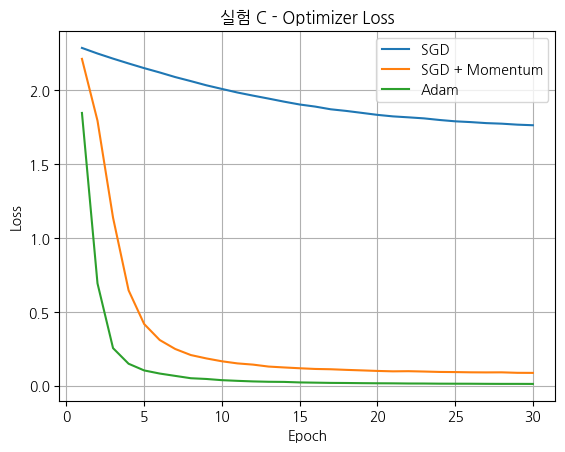

In [59]:
# 실험 C Loss 그래프

plt.plot(sgd_epoch, sgd_loss, label="SGD")
plt.plot(momentum_epoch, momentum_loss, label="SGD + Momentum")
plt.plot(adam_epoch, adam_loss, label="Adam")

plt.title("실험 C - Optimizer Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid()
plt.show()

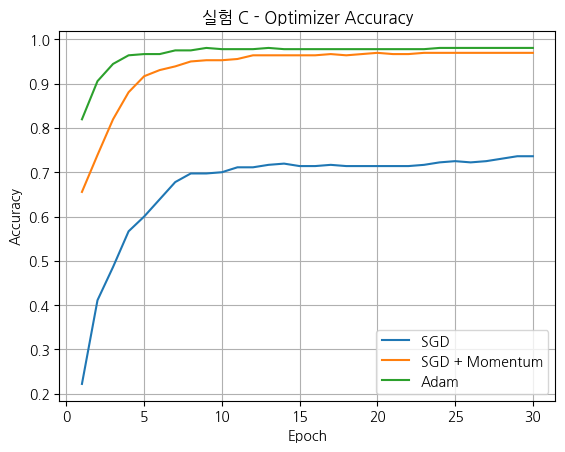

In [60]:
# 실험 C Accuracy 그래프

plt.plot(sgd_epoch, sgd_acc, label="SGD")
plt.plot(momentum_epoch, momentum_acc, label="SGD + Momentum")
plt.plot(adam_epoch, adam_acc, label="Adam")

plt.title("실험 C - Optimizer Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()
plt.show()

In [54]:
# Gradient Flow 시각화
def show_gradient_flow(model, title):

    layer_names = []
    gradient_values = []

    for name, param in model.named_parameters():

        # weight에 해당하고 gradient가 존재하는 경우만 확인
        if "weight" in name and param.grad is not None:
            layer_names.append(name)
            gradient_values.append(param.grad.abs().mean().item())

    plt.bar(layer_names, gradient_values)
    plt.title(title + " Gradient Flow")
    plt.xlabel("Layer")
    plt.ylabel("Mean Gradient")
    plt.xticks(rotation=45)
    plt.grid()
    plt.show()

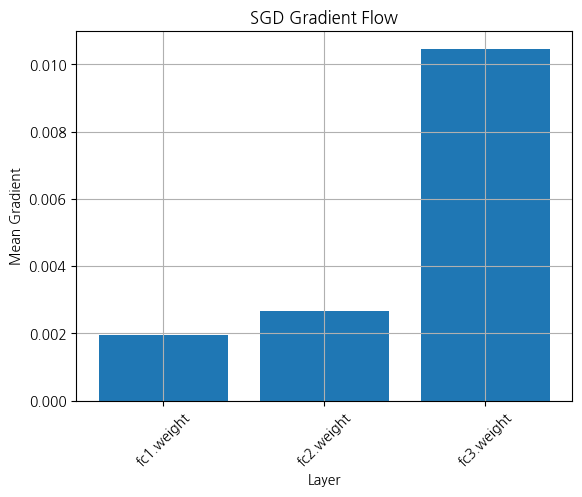

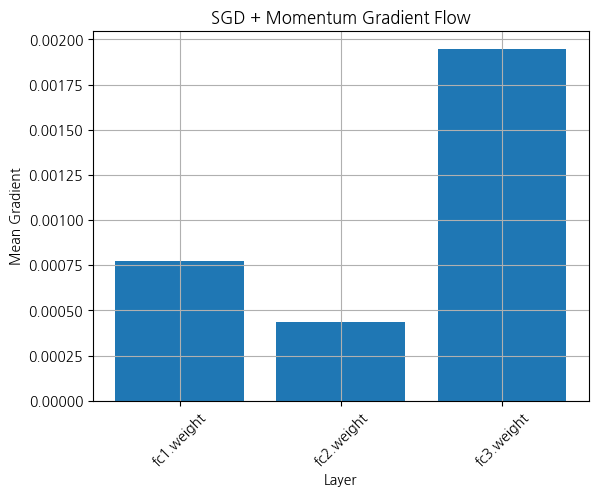

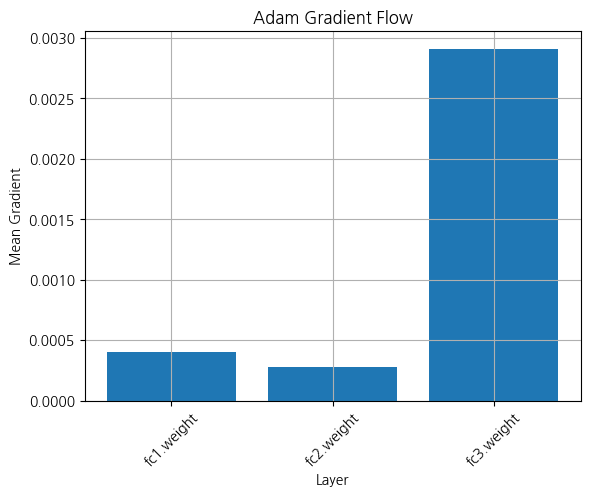

In [55]:
show_gradient_flow(sgd_model, "SGD")
show_gradient_flow(momentum_model, "SGD + Momentum")
show_gradient_flow(adam_model, "Adam")

In [56]:
# 실험 C 비교 표

optimizer_table = pd.DataFrame({
    "Optimizer": ["SGD", "SGD + Momentum", "Adam"],
    "Learning Rate": [0.01, 0.01, 0.001],
    "최종 정확도": [sgd_acc[-1], momentum_acc[-1], adam_acc[-1]],
    "Loss 최소값": [min(sgd_loss), min(momentum_loss), min(adam_loss)]
})

optimizer_table

,Optimizer,Learning Rate,최종 정확도,Loss 최소값
0,SGD,0.010,0.736111,1.764680
1,SGD + Momentum,0.010,0.969444,0.088605
2,Adam,0.001,0.980556,0.013929


sgd lr: 0.1 Epoch: 1 Loss: 2.1043504165566485 Test Accuracy: 0.6833333333333333
sgd lr: 0.1 Epoch: 2 Loss: 1.4084634210752405 Test Accuracy: 0.8166666666666667
sgd lr: 0.1 Epoch: 3 Loss: 0.7520312628020411 Test Accuracy: 0.8694444444444445
sgd lr: 0.1 Epoch: 4 Loss: 0.46781224530676135 Test Accuracy: 0.9138888888888889
sgd lr: 0.1 Epoch: 5 Loss: 0.33649218924667523 Test Accuracy: 0.9388888888888889
sgd lr: 0.1 Epoch: 6 Loss: 0.26180606886096625 Test Accuracy: 0.9444444444444444
sgd lr: 0.1 Epoch: 7 Loss: 0.21750544335531152 Test Accuracy: 0.9444444444444444
sgd lr: 0.1 Epoch: 8 Loss: 0.18674317002296448 Test Accuracy: 0.9472222222222222
sgd lr: 0.1 Epoch: 9 Loss: 0.17205861858699634 Test Accuracy: 0.9638888888888889
sgd lr: 0.1 Epoch: 10 Loss: 0.14788780167050983 Test Accuracy: 0.9555555555555556
sgd lr: 0.1 Epoch: 11 Loss: 0.13627161506725394 Test Accuracy: 0.9555555555555556
sgd lr: 0.1 Epoch: 12 Loss: 0.12929979517408038 Test Accuracy: 0.9638888888888889
sgd lr: 0.1 Epoch: 13 Loss: 

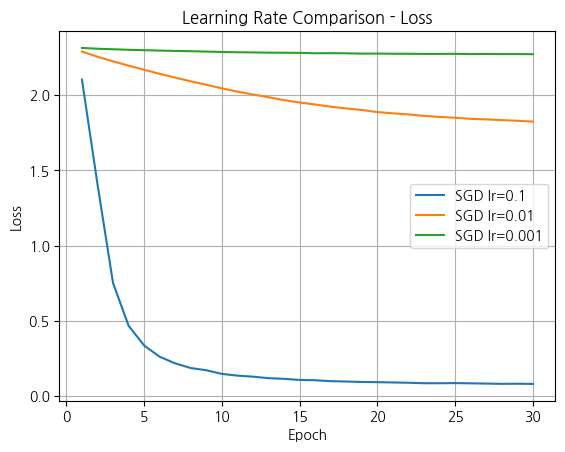

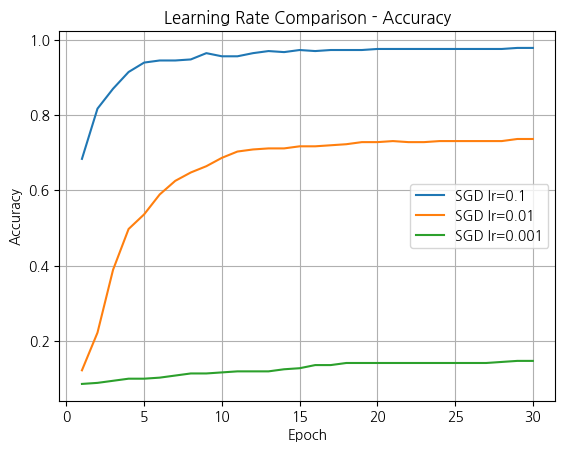

In [57]:
# 학습률에 따른 변화 싷험
# SGD 기준으로 0.1, 0.01, 0.001 비교

sgd_01_model, sgd_01_epoch, sgd_01_loss, sgd_01_acc = train_optimizer_model(
    "sgd",
    0.1
)

sgd_001_model, sgd_001_epoch, sgd_001_loss, sgd_001_acc = train_optimizer_model(
    "sgd",
    0.01
)

sgd_0001_model, sgd_0001_epoch, sgd_0001_loss, sgd_0001_acc = train_optimizer_model(
    "sgd",
    0.001
)

# 학습률 별 Loss
plt.plot(sgd_01_epoch, sgd_01_loss, label="SGD lr=0.1")
plt.plot(sgd_001_epoch, sgd_001_loss, label="SGD lr=0.01")
plt.plot(sgd_0001_epoch, sgd_0001_loss, label="SGD lr=0.001")

plt.title("Learning Rate Comparison - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid()
plt.show()

## Accuracy
plt.plot(sgd_01_epoch, sgd_01_acc, label="SGD lr=0.1")
plt.plot(sgd_001_epoch, sgd_001_acc, label="SGD lr=0.01")
plt.plot(sgd_0001_epoch, sgd_0001_acc, label="SGD lr=0.001")

plt.title("Learning Rate Comparison - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()
plt.show()

In [61]:
# 학습률별 비교 표

lr_table = pd.DataFrame({
    "Optimizer": ["SGD", "SGD", "SGD"],
    "Learning Rate": [0.1, 0.01, 0.001],
    "최종 정확도": [sgd_01_acc[-1], sgd_001_acc[-1], sgd_0001_acc[-1]],
    "Loss 최솟값": [min(sgd_01_loss), min(sgd_001_loss), min(sgd_0001_loss)]
})

lr_table

,Optimizer,Learning Rate,최종 정확도,Loss 최솟값
0,SGD,0.100,0.977778,0.081170
1,SGD,0.010,0.736111,1.825013
2,SGD,0.001,0.147222,2.273038
